# TDE #2 — Estacionariedade, Testes de Independência e Modelos ARIMA
**Previsão de Séries Temporais — PUCRS**  ·  Gabriel Floriano

Continuação do TDE #1: as seções abaixo (Parte I) recapitulam a preparação e a análise exploratória; a **Parte II (TDE #2)** aplica Box & Jenkins sobre a mesma série mensal de ocorrências do RS (`serie`).

## 1. Recontextualização
- **Domínio:** segurança pública — ocorrências criminais por estado no Brasil.
- **Problema:** entender a evolução temporal (tendência e sazonalidade) das ocorrências para apoiar planejamento de segurança.
- **Fonte / dataset:** *Crimes no Brasil por estado* — Kaggle: https://www.kaggle.com/datasets/vianags/crimes-no-brasil-por-estado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.filters import hp_filter
from scipy import stats
import kagglehub

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

C:\Users\gabri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Preparação e classificação dos dados

In [2]:
df = pd.read_csv(r"Crimes_brasil_uf.csv")

In [3]:
# Estrutura do dataset
df["Data"] = pd.to_datetime(df["Data"])   # converte Data (texto) -> datetime
print("Colunas:", df.columns.tolist())
print("UFs:", df["Uf"].nunique(), "| Tipos de crime:", df["Tipo_crime"].nunique())
print("Período:", df["Data"].min().date(), "->", df["Data"].max().date())
df.head()

Colunas: ['Uf', 'Tipo_crime', 'Ocorrencias', 'Data']
UFs: 27 | Tipos de crime: 9
Período: 2015-01-01 -> 2022-09-01


,Uf,Tipo_crime,Ocorrencias,Data
0,Acre,Estupro,31,2022-01-01
1,Acre,Furto de veículo,50,2022-01-01
2,Acre,Homicídio doloso,10,2022-01-01
3,Acre,Lesão corporal seguida de morte,1,2022-01-01
4,Acre,Roubo a instituição financeira,0,2022-01-01


In [4]:
# Inspeção rápida para decidir os nomes de coluna abaixo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22338 entries, 0 to 22337
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Uf           22338 non-null  object        
 1   Tipo_crime   22338 non-null  object        
 2   Ocorrencias  22338 non-null  int64         
 3   Data         22338 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 698.2+ KB


In [5]:
# CONFIG de colunas — nomes reais do dataset
COL_DATA  = "Data"
COL_ANO   = None
COL_MES   = None
COL_UF    = "Uf"
COL_CRIME = "Tipo_crime"
COL_VALOR = "Ocorrencias"

UF_ESCOLHIDA    = "Rio Grande do Sul"   # estado a analisar
CRIME_ESCOLHIDO = None                  # None = soma todos os crimes; ex.: "Homicídio doloso"

In [6]:
# Constrói a data mensal (usa COL_DATA se existir; senão monta a partir de ano/mes)
if COL_DATA in df.columns:
    df["_data"] = pd.to_datetime(df[COL_DATA])
else:
    df["_data"] = pd.to_datetime(dict(year=df[COL_ANO], month=df[COL_MES], day=1))

# Filtros: estado e (opcionalmente) tipo de crime
base = df[df[COL_UF] == UF_ESCOLHIDA].copy()
if COL_CRIME and CRIME_ESCOLHIDO:
    base = base[base[COL_CRIME] == CRIME_ESCOLHIDO]

# Agrega para série mensal (soma de ocorrências por mês)
serie = base.groupby("_data")[COL_VALOR].sum().sort_index()
serie = serie.asfreq("MS")   # frequência mensal explícita -> revela lacunas como NaN
serie.head()

_data
2015-01-01    4112
2015-02-01    3749
2015-03-01    4164
2015-04-01    3821
2015-05-01    3925
Freq: MS, Name: Ocorrencias, dtype: int64

In [7]:
# Consistência temporal: lacunas e duplicidades
print("Período:", serie.index.min(), "→", serie.index.max())
print("Nº de observações:", len(serie))
print("Meses faltantes (NaN):", int(serie.isna().sum()))
print("Datas duplicadas:", int(serie.index.duplicated().sum()))

# Tratamento de lacunas: interpolação temporal (se houver poucos buracos)
serie = serie.interpolate("time")

Período: 2015-01-01 00:00:00 → 2022-09-01 00:00:00
Nº de observações: 93
Meses faltantes (NaN): 0
Datas duplicadas: 0


**Classificação da série:** quantitativa, univariada, de frequência **mensal** e (após o `asfreq`)
**regularmente espaçada**. Contagem de ocorrências ≥ 0.

## 3. Gráficos

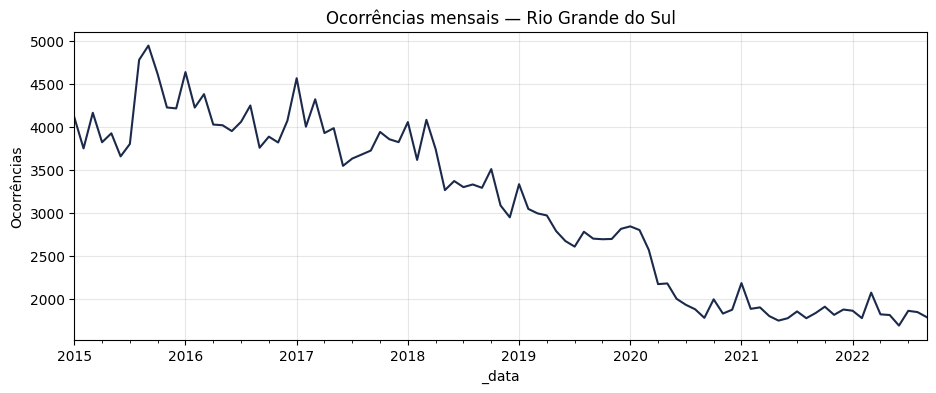

In [8]:
# a) Timeplot
serie.plot(title=f"Ocorrências mensais — {UF_ESCOLHIDA}", color="#1B2A4A")
plt.ylabel("Ocorrências"); plt.show()

A série cai de forma acentuada de ~4.100 ocorrências/mês em 2015 para ~1.800 em 2022 (queda de ~57%). O padrão dominante é uma **tendência de queda**, sem saltos bruscos ou quebras abruptas.

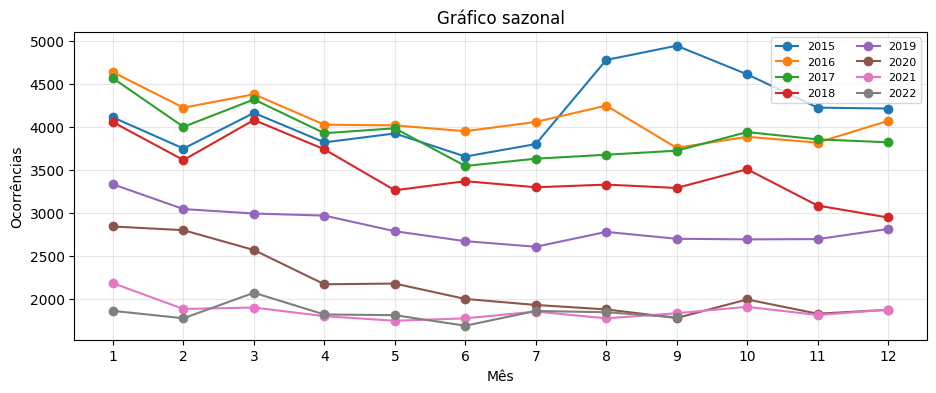

In [9]:
# b) Seasonal plot — uma linha por ano, meses no eixo X
aux = serie.to_frame("valor")
aux["ano"] = aux.index.year
aux["mes"] = aux.index.month

fig, ax = plt.subplots()
for ano, g in aux.groupby("ano"):
    ax.plot(g["mes"], g["valor"], marker="o", label=str(ano))
ax.set_xticks(range(1, 13)); ax.set_xlabel("Mês"); ax.set_ylabel("Ocorrências")
ax.set_title("Gráfico sazonal"); ax.legend(ncol=2, fontsize=8); plt.show()

Cada linha é um ano, e os anos mais recentes ficam  **abaixo** dos anteriores (tendência de queda). O formato das linhas repete um leve **pico no começo do ano (jan–mar)** e vale no meio do ano, indicando uma sazonalidade fraca.

* Única divergência fica para ago à out de 2015, valeria investigar acontecimentos que possívelmente intensificaram isso.

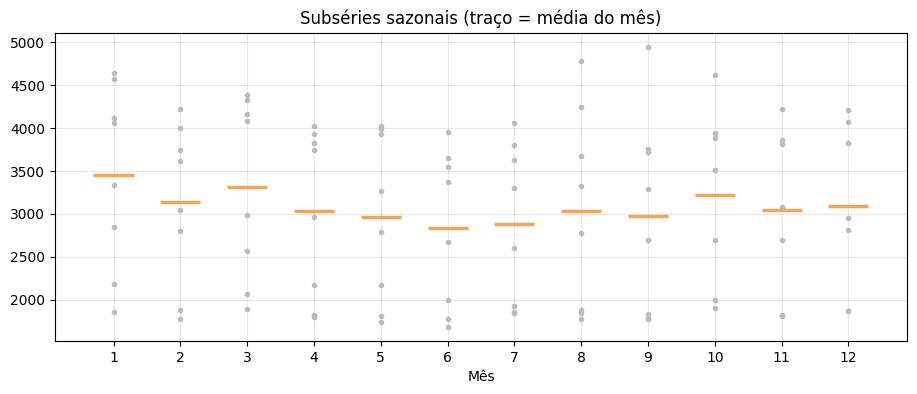

In [10]:
# c) Subséries sazonais — média de cada mês ao longo dos anos
media_mes = aux.groupby("mes")["valor"].mean()
fig, ax = plt.subplots()
for mes, g in aux.groupby("mes"):
    ax.plot([mes]*len(g), g["valor"], "o", color="#BBB", markersize=3)
    ax.hlines(media_mes[mes], mes-0.3, mes+0.3, color="#F2A65A", linewidth=2.5)
ax.set_xticks(range(1, 13)); ax.set_xlabel("Mês"); ax.set_title("Subséries sazonais (traço = média do mês)")
plt.show()

Cada ponto é um mês de um ano, o traço laranja é a média do mês. 

* A grande dispersão vertical vem da **tendência** (anos antigos no topo, recentes embaixo). 
* As médias mensais variam pouco (~600), confirmando **sazonalidade fraca** (janeiro mais alto, junho mais baixo).

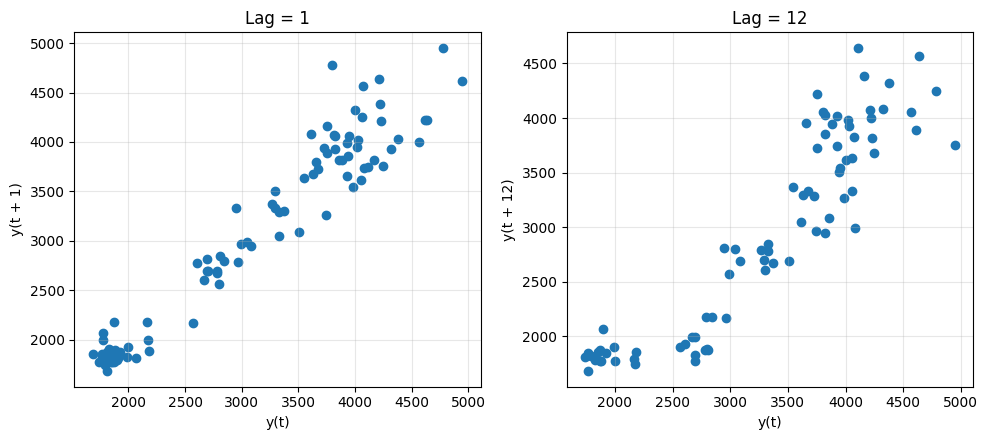

In [11]:
# d) Lag plot com 2 lags diferentes
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, lag in zip(axes, [1, 12]):
    pd.plotting.lag_plot(serie, lag=lag, ax=ax)
    ax.set_title(f"Lag = {lag}")
plt.tight_layout(); plt.show()

Os pontos ficam quase sobre a diagonal, no lag 1 (autocorrelação 0,97) e no lag 12 (0,92). Isso indica **forte dependência temporal**, ou seja cada mês é muito parecido com o mês anterior e com o mesmo mês do ano passado.

## 4. Transformação (log / Box-Cox)

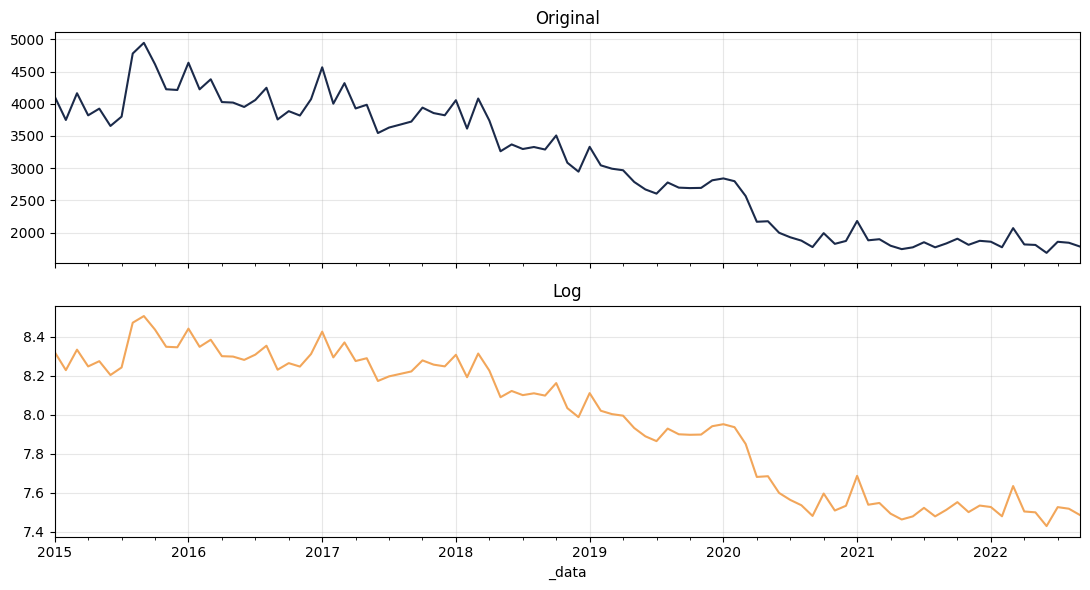

Lambda Box-Cox: 0.754


In [12]:
# Compara série original vs log (estabiliza variância se ela cresce com o nível)
serie_log = np.log(serie.replace(0, np.nan)).interpolate("time")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie.plot(ax=axes[0], title="Original", color="#1B2A4A")
serie_log.plot(ax=axes[1], title="Log", color="#F2A65A")
plt.tight_layout(); plt.show()

# Box-Cox (opcional) — retorna também o lambda ótimo
bc, lam = stats.boxcox(serie[serie > 0])
print("Lambda Box-Cox:", round(lam, 3))

A variação relativa da série não cresce com o nível (fica em ~6–8%) e o λ de Box-Cox deu **0,75 (próximo de 1)**. A transformação log/Box-Cox **quase não altera** a série, sendo **dispensável** neste caso.

## 5. Decomposição

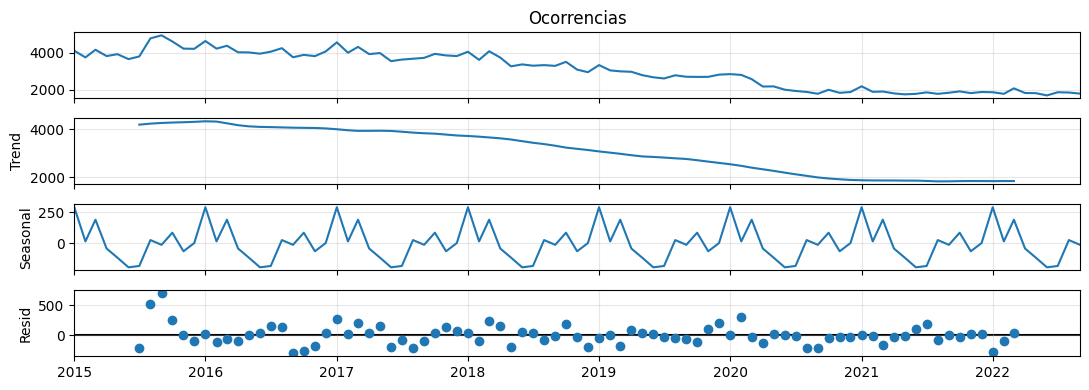

In [13]:
# Escolha aditivo x multiplicativo: multiplicativo se a amplitude sazonal cresce com o nível.
MODELO = "additive"   # ou "multiplicative"
dec = seasonal_decompose(serie, model=MODELO, period=12)
dec.plot(); plt.tight_layout(); plt.show()

Conclusão para cada decomposição foi:
* **Tendência** domina (varia ~2.500, a queda de longo prazo)
* **Sazonalidade** é pequena e repetitiva (~500)
* **Resíduo** é baixo (~160) e sem padrão aparente. 

## 6. Diferenciação

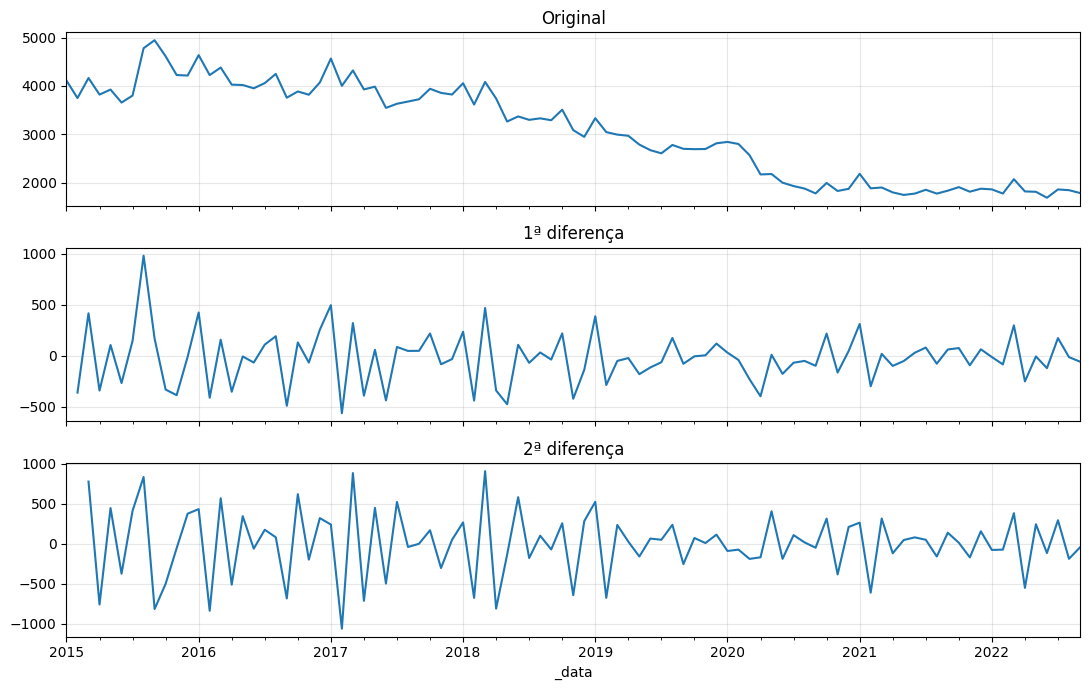

In [14]:
d1 = serie.diff()
d2 = serie.diff().diff()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, dado, nome in zip(axes, [serie, d1, d2], ["Original", "1ª diferença", "2ª diferença"]):
    dado.plot(ax=ax, title=nome)
plt.tight_layout(); plt.show()

Uma diferença já **remove a tendência** e estabiliza a série (desvio cai de ~970 para ~250). A segunda diferença **piora** (sobe para ~410), sinal de sobre-diferenciação.

## 7. Suavização (mediana móvel vs média móvel)

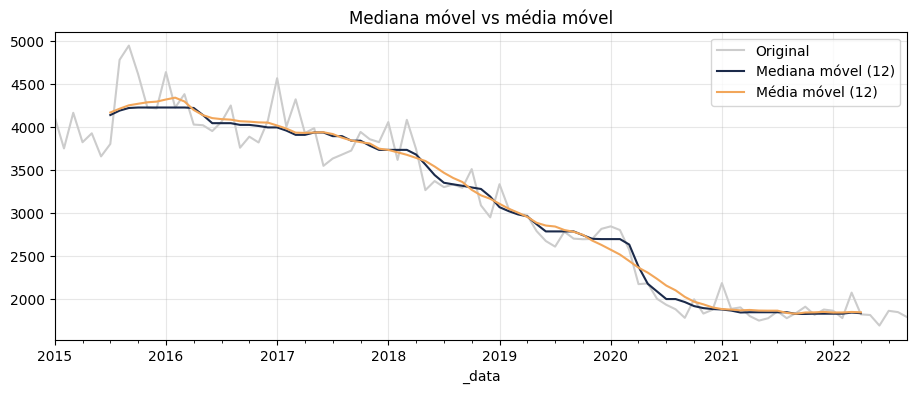

In [15]:
JANELA = 12
med_movel = serie.rolling(JANELA, center=True).median()
media_movel = serie.rolling(JANELA, center=True).mean()

serie.plot(label="Original", color="#CCC")
med_movel.plot(label=f"Mediana móvel ({JANELA})", color="#1B2A4A")
media_movel.plot(label=f"Média móvel ({JANELA})", color="#F2A65A")
plt.legend(); plt.title("Mediana móvel vs média móvel"); plt.show()

As duas suavizações revelam a mesma **tendência de queda**, filtrando o ruído mensal. 
* A **mediana móvel** é mais robusta a picos isolados.
* Ja **média móvel** é um pouco mais suave, porém mais sensível a valores extremos.

## 8. Filtros

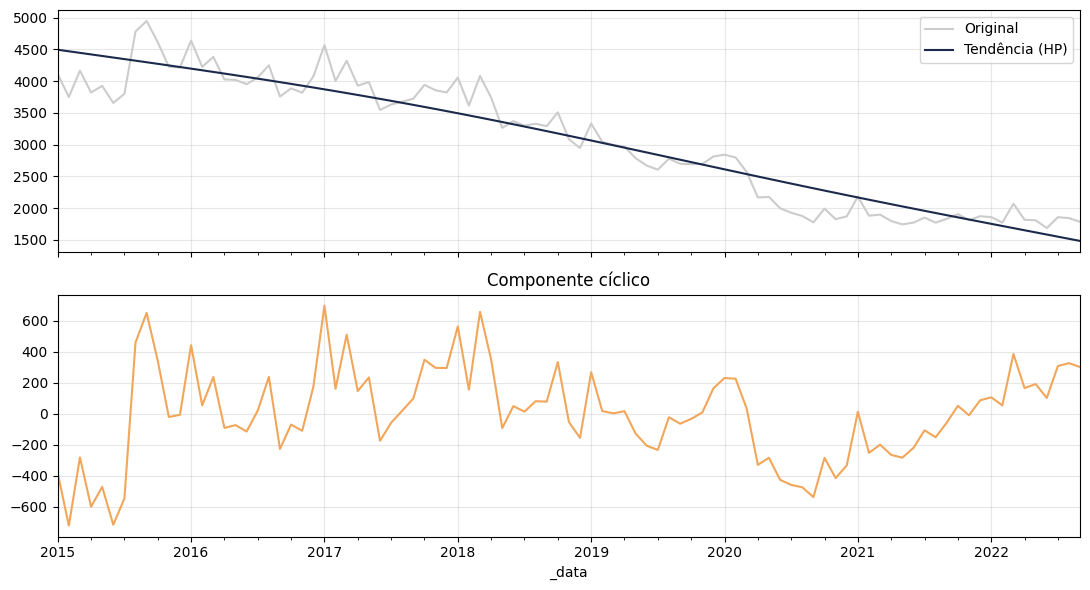

In [16]:
# Filtro Hodrick-Prescott: separa tendência suave + componente cíclico
ciclo, tendencia = hp_filter.hpfilter(serie, lamb=129600)  # lamb mensal

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie.plot(ax=axes[0], label="Original", color="#CCC")
tendencia.plot(ax=axes[0], label="Tendência (HP)", color="#1B2A4A"); axes[0].legend()
ciclo.plot(ax=axes[1], title="Componente cíclico", color="#F2A65A")
plt.tight_layout(); plt.show()

O filtro HP separa a série em uma **tendência suave** (a queda de longo prazo) e um **ciclo** (desvios de curto prazo em torno dela). Ajuda a ver períodos acima/abaixo do nível esperado sem o ruído mês a mês.

## 9. Síntese comparativa

Comparando as técnicas aplicadas, o padrão que se repete em todas é a **tendência de queda** (~57% de 2015 a 2022); a **sazonalidade** é fraca.

**Técnicas que ajudaram:**
- **Timeplot** — mostrou a queda acentuada e a ausência de saltos/quebras.
- **Decomposição** — informativa: separou a tendência (dominante, ~2.500), a sazonalidade (pequena, ~500) e o resíduo (baixo, ~160), confirmando quem manda na série.
- **Diferenciação** — uma diferença remove a tendência e estabiliza a série (desvio 970→250); a 2ª piora (sobre-diferenciação).
- **Lag plot** — evidenciou forte dependência temporal (autocorrelação 0,97 no lag 1), indicando que a série é previsível a partir do próprio passado.
- **Suavização / Filtro HP** — úteis para "limpar" o ruído mensal e enxergar a tendência de longo prazo com clareza.

**Técnicas que pouco agregaram:**
- **Gráficos sazonais / subséries** — a sazonalidade existe (pico jan–mar, vale jun–jul), mas é tão pequena que fica ofuscada pela tendência; só aparece melhor na decomposição.
- **Transformação (log / Box-Cox)** — dispensável: a variância não cresce com o nível e o λ≈0,75 (perto de 1) quase não altera a série.

**Interpretação geral:** para este domínio, o fenômeno é essencialmente uma **forte tendência de queda com forte dependência temporal e pouca sazonalidade**. Isso indica que, antes de modelar, é preciso **remover a tendência (diferenciação)** — exatamente o caminho seguido no TDE #2, onde a série exigiu d=1 e foi bem descrita por um ARIMA(0,1,1).

---
# Parte II - TDE #2 (Box & Jenkins / ARIMA)
A partir daqui usamos a mesma série mensal `serie` (total de ocorrências do RS).

In [17]:
import warnings; warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

# Função auxiliar: roda ADF e KPSS juntos e já interpreta (alfa = 5%)
def testa_estacionariedade(x, nome=""):
    x = x.dropna()
    adf = adfuller(x, autolag="AIC")
    kps = kpss(x, regression="c", nlags="auto")
    print(f"[{nome}] ADF : stat={adf[0]:7.3f}  p={adf[1]:.4f}  -> " +
          ("estacionária" if adf[1] < 0.05 else "NÃO estacionária"))
    print(f"[{nome}] KPSS: stat={kps[0]:7.3f}  p={kps[1]:.4f}  -> " +
          ("estacionária" if kps[1] > 0.05 else "NÃO estacionária"))

## 1. Testes formais de estacionariedade (série em nível)

In [18]:
testa_estacionariedade(serie, "nível")

[nível] ADF : stat= -1.057  p=0.7319  -> NÃO estacionária
[nível] KPSS: stat=  1.568  p=0.0100  -> NÃO estacionária


ADF não rejeita a raiz unitária (p≈0,73) e KPSS rejeita a estacionariedade (p≈0,01). **Os dois concordam: a série em nível NÃO é estacionária** — resultado esperado, pois ela tem forte tendência de queda. Precisamos diferenciar.

## 2. Diferenciação guiada pelos testes

[1ª diferença] ADF : stat= -3.219  p=0.0189  -> estacionária
[1ª diferença] KPSS: stat=  0.084  p=0.1000  -> estacionária


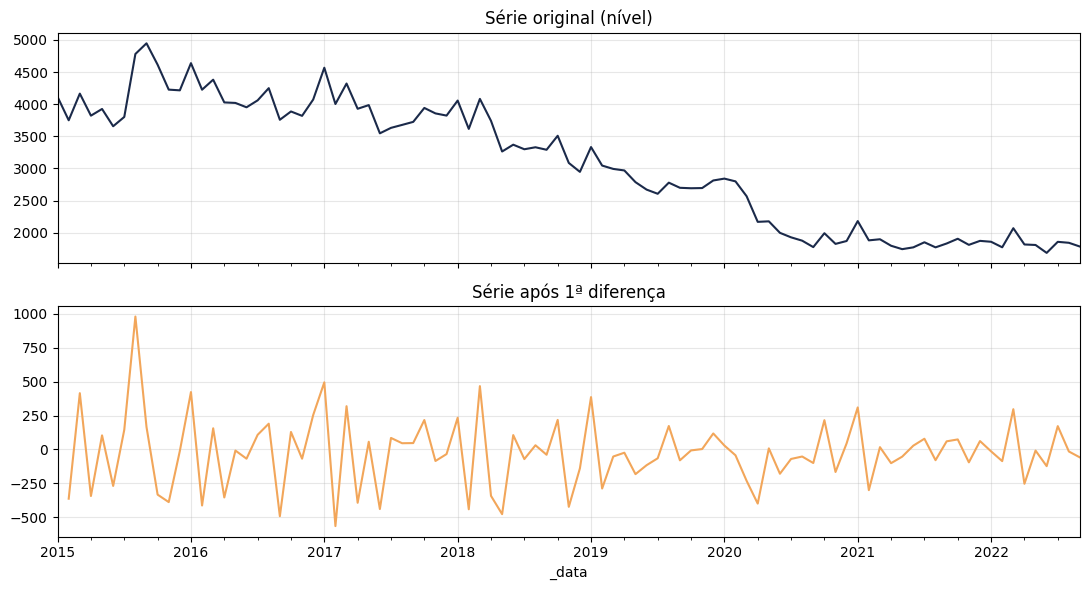

In [19]:
d1 = serie.diff()
testa_estacionariedade(d1, "1ª diferença")

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie.plot(ax=ax[0], title="Série original (nível)", color="#1B2A4A")
d1.plot(ax=ax[1], title="Série após 1ª diferença", color="#F2A65A")
plt.tight_layout(); plt.show()

Após uma diferença, ADF passa a rejeitar a raiz unitária (p≈0,02) e KPSS não rejeita a estacionariedade (p≈0,10). **Ambos concordam: a série fica estacionária com d = 1.** Uma diferença basta. O gráfico confirma: some a tendência e a série passa a oscilar em torno de zero.

## 3. Identificação de p e q via ACF/PACF

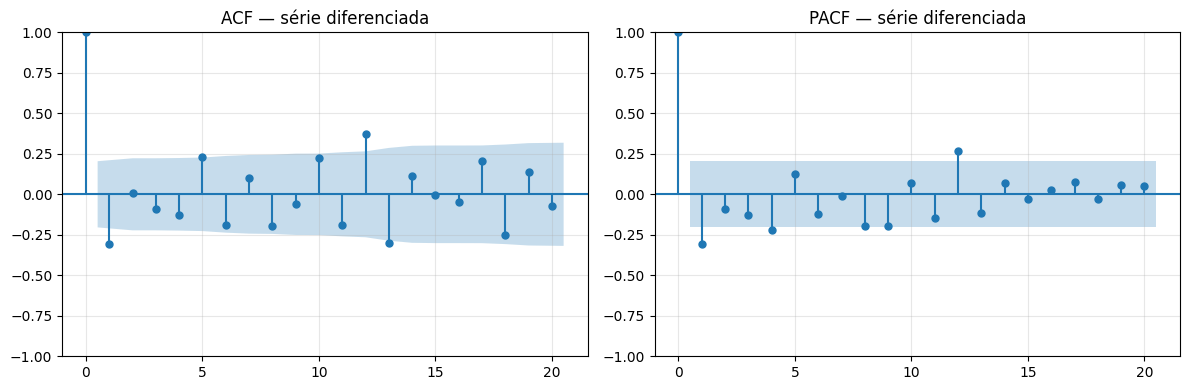

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(d1.dropna(),  lags=20, ax=ax[0]); ax[0].set_title("ACF — série diferenciada")
plot_pacf(d1.dropna(), lags=20, ax=ax[1], method="ywm"); ax[1].set_title("PACF — série diferenciada")
plt.tight_layout(); plt.show()

**ACF** tem um único pico significativo e negativo no lag 1 e depois cai para dentro das bandas; a **PACF** decai gradualmente. Candidato principal: **(p,d,q) = (0,1,1)**.

## 4. Teste de independência - Ljung-Box (série bruta)

In [21]:
lb_bruta = acorr_ljungbox(serie, lags=[6, 12], return_df=True)
print(lb_bruta)

       lb_stat      lb_pvalue
6   466.411731   1.439305e-97
12  815.220671  9.004762e-167


p-valores ~ 0 → **rejeita a independência**: a série bruta tem forte autocorrelação (não é ruído branco), o que já era esperado por causa da tendência.

## 5. Ajuste do modelo ARIMA (manual × automático)

In [22]:
# 5a) candidatos manuais (da leitura ACF/PACF)
candidatos = [(0,1,1), (1,1,0), (1,1,1)]
aic_manual = {}
for ordem in candidatos:
    aic_manual[ordem] = ARIMA(serie, order=ordem).fit().aic
    print(f"ARIMA{ordem}  AIC = {aic_manual[ordem]:.2f}")

melhor_manual = min(aic_manual, key=aic_manual.get)
print("Melhor manual (menor AIC):", melhor_manual)

# 5b) busca automática
auto = pm.auto_arima(serie, seasonal=False, stepwise=True,
                     suppress_warnings=True, error_action="ignore")
print("auto_arima ->", auto.order, "| AIC =", round(auto.aic(), 2))

ARIMA(0, 1, 1)  AIC = 1273.79
ARIMA(1, 1, 0)  AIC = 1274.80
ARIMA(1, 1, 1)  AIC = 1275.48
Melhor manual (menor AIC): (0, 1, 1)


auto_arima -> (0, 1, 1) | AIC = 1273.48


Entre os candidatos manuais, o **(0,1,1)** teve o menor AIC (~1273,8), à frente de (1,1,0) e (1,1,1). O **auto_arima chega ao mesmo modelo (0,1,1)** (AIC ~1273,5). **Manual e automático concordam**, a escolha de modelo final foi o **ARIMA(0,1,1)**.

## 6. Diagnóstico dos resíduos

                               SARIMAX Results                                
Dep. Variable:            Ocorrencias   No. Observations:                   93
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -634.895
Date:                Mon, 05 Oct 2026   AIC                           1273.791
Time:                        11:16:59   BIC                           1278.834
Sample:                    01-01-2015   HQIC                          1275.826
                         - 09-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3550      0.082     -4.324      0.000      -0.516      -0.194
sigma2      5.782e+04   5817.136      9.940      0.000    4.64e+04    6.92e+04
Ljung-Box (L1) (Q):                   0.00   Jarque-

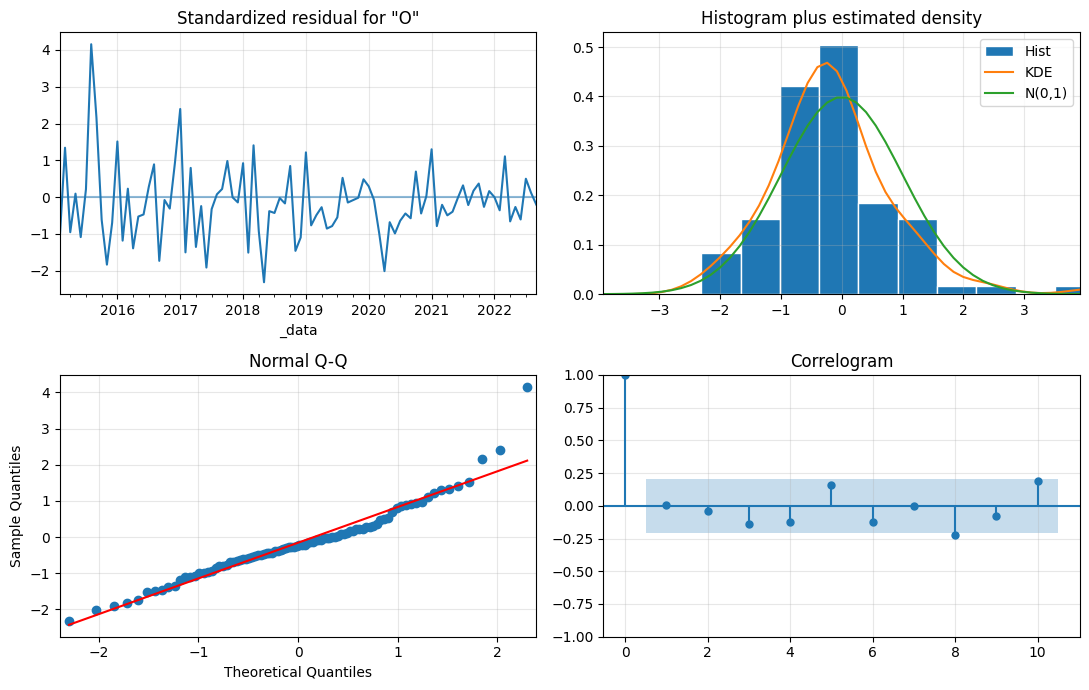

In [23]:
modelo_final = ARIMA(serie, order=(0,1,1)).fit()
print(modelo_final.summary())

resid = modelo_final.resid
print("\nLjung-Box nos resíduos:")
print(acorr_ljungbox(resid, lags=[6, 12], return_df=True))
print()
testa_estacionariedade(resid, "resíduos")

modelo_final.plot_diagnostics(figsize=(11, 7)); plt.tight_layout(); plt.show()

Nos resíduos, o **Ljung-Box não rejeita a independência** (p~0,80), ou seja, viraram **ruído branco**, diferente da série bruta (p~0). ADF/KPSS indicam resíduos estacionários e os gráficos de diagnóstico não mostram padrão/autocorrelação relevante. **O modelo (0,1,1) é aprovado**, não sendo necessário testar outras ordens.

## 7. Previsão (2 horizontes, IC 95%)

Horizonte 6 meses -> previsão vai de 1800 a 1800
Horizonte 12 meses -> previsão vai de 1800 a 1800


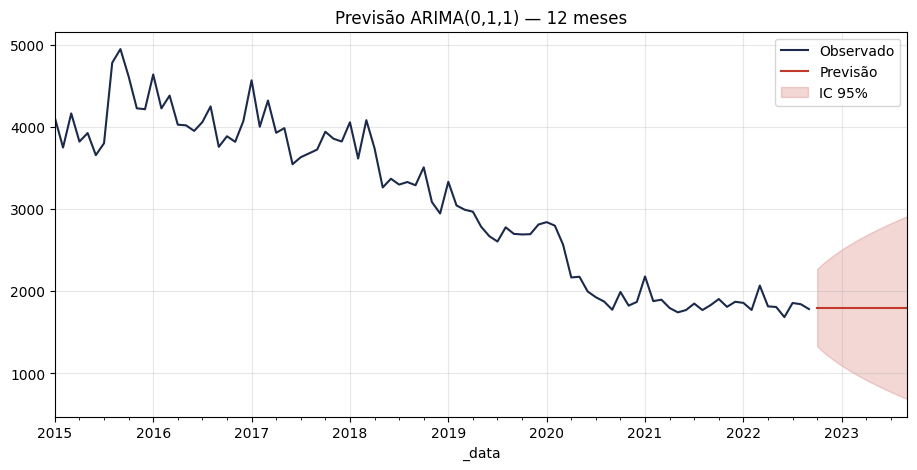

In [24]:
for h in [6, 12]:
    fc = modelo_final.get_forecast(steps=h)
    print(f"Horizonte {h} meses -> previsão vai de {fc.predicted_mean.iloc[0]:.0f} a {fc.predicted_mean.iloc[-1]:.0f}")

# plota a série + previsão de 12 meses com IC 95%
h = 12
fc = modelo_final.get_forecast(steps=h)
media = fc.predicted_mean
ic = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(11, 5))
serie.plot(ax=ax, label="Observado", color="#1B2A4A")
media.plot(ax=ax, label="Previsão", color="#C0392B")
ax.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color="#C0392B", alpha=0.2, label="IC 95%")
ax.set_title("Previsão ARIMA(0,1,1) — 12 meses"); ax.legend(); plt.show()

A previsão é praticamente **uma linha plana (~1.800)**, projetando o último nível observado com o intervalo de confiança se alargando ao longo do tempo. Isso é típico de um ARIMA(0,1,1), ele captura o **nível** e a **incerteza crescente**, mas é um modelo **simples** e não reproduz a sazonalidade fraca nem uma eventual retomada de tendência.

## 8. Síntese
- **Estacionariedade:** série não estacionária em nível (ADF+KPSS concordam); **d = 1** é suficiente.
- **Identificação:** ACF/PACF apontam **MA(1)** -> (0,1,1).
- **Manual × automático:** ambos escolhem **ARIMA(0,1,1)** (AICs praticamente iguais), o que dá confiança na especificação.
- **Resíduos:** viraram ruído branco (Ljung-Box p~0,80) -> modelo bem ajustado.
- **Limitações:** a previsão é quase plana e o modelo é **não sazonal**, a série é curta (93 meses) e dominada pela queda. No geral, o resultado é **satisfatório** para o objetivo de Box & Jenkins, mas há espaço para melhora na parte preditiva.